In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [81]:
df = pd.read_csv("student_data.csv")

print("Shape:", df.shape)
df.head()


Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [82]:
df.drop_duplicates(inplace=True)

print("Missing Values:\n", df.isnull().sum())

Missing Values:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


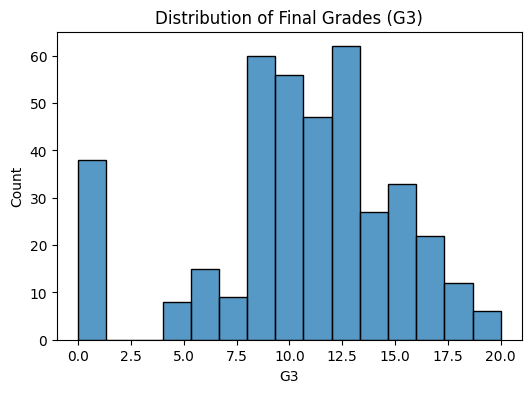

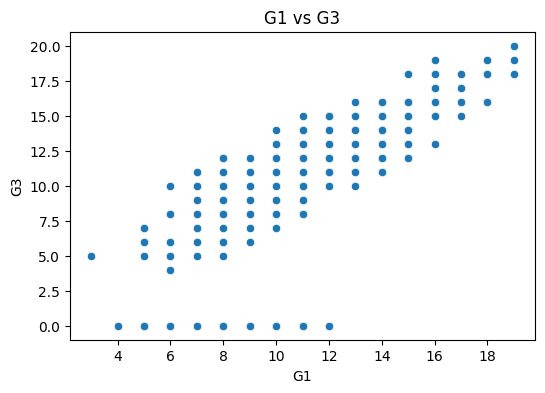

In [83]:
# Distribution of final grades
plt.figure(figsize=(6,4))
sns.histplot(df['G3'], bins=15)
plt.title("Distribution of Final Grades (G3)")
plt.show()

# Relationship between G1 and G3
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['G1'], y=df['G3'])
plt.title("G1 vs G3")
plt.show()


In [84]:
features = ['sex', 'age', 'studytime', 'failures', 'absences', 'G1', 'G2']
df_model = df[features + ['G3']].copy()


In [85]:
df_model['result'] = (df_model['G3'] >= 10).astype(int)
df_model.drop('G3', axis=1, inplace=True)

df_model.head()


,sex,age,studytime,failures,absences,G1,G2,result
0,F,18,2,0,6,5,6,0
1,F,17,2,0,4,5,5,0
2,F,15,2,3,10,7,8,1
3,F,15,3,0,2,15,14,1
4,F,16,2,0,4,6,10,1


In [86]:
df_model['sex'] = df_model['sex'].map({'F': 0, 'M': 1})


In [91]:
X = df_model.drop('result', axis=1)
y = df_model['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [92]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [93]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [96]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Precision, Recall, F1-score
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))

Accuracy: 0.8860759493670886

Confusion Matrix:
 [[22  5]
 [ 4 48]]

Classification Report:

              precision    recall  f1-score   support

        Fail       0.85      0.81      0.83        27
        Pass       0.91      0.92      0.91        52

    accuracy                           0.89        79
   macro avg       0.88      0.87      0.87        79
weighted avg       0.89      0.89      0.89        79



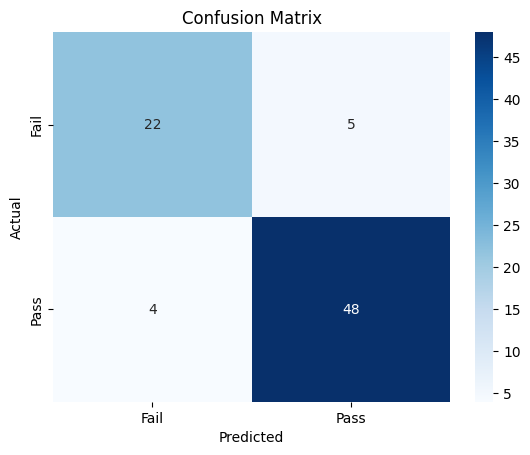

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [98]:
sample = [[1, 17, 2, 0, 5, 10, 12]]

sample = scaler.transform(sample)

prediction = model.predict(sample)

print("Prediction:", "Pass" if prediction[0] == 1 else "Fail")


Prediction: Pass
